# About

This notebook provides an example of using the COMSOL model generator to solve the scattering of an acoustic spherical wave by a Helmholtz resonator.


# Example

The COMSOL model evaluates the extinction power
$$
W_\text{ext} = - \int r^2 d\Omega \frac{1}{2}\text{Re}\left[ p_\text{s}^* (\vec{v}_\text{b}\cdot \vec{n}) + p_\text{b}^* (\vec{v}_\text{s}\cdot \vec{n}) \right]
$$
For a spherical surface of radius $R_\text{int}$:
$$
W_\text{ext} = \frac{1}{2\omega\rho_\text{host}} \int R_\text{int}^2 d\Omega \text{Im}\left[ p_\text{s}^* \left(\frac{\partial p_\text{b}}{\partial \vec{r}}\cdot \vec{r}\right) + p_\text{b}^* \left(\frac{\partial p_\text{s}}{\partial \vec{r}}\cdot \vec{r}\right) \right]
$$

The model also defines variables for calculating the scattering power:
$$
W_\text{sc} = -\frac{1}{2\omega\rho_\text{host}} \int R_\text{int}^2 d\Omega \text{Im}\left[ p_\text{s}^* \left(\frac{\partial p_\text{s}}{\partial \vec{r}}\cdot \vec{r}\right) \right]
$$


The extinction and scattering cross-sections are then obtained as
$$
\sigma_\text{ext} = \frac{W_\text{ext}}{I_0}
$$
$$
\sigma_\text{sc} = \frac{W_\text{sc}}{I_0}
$$
where $I_0 = p_0^2 / (2c_\text{host}\rho_\text{host})$ is the intensity of the incident plane wave.

In [1]:
# In case something goes wrong, you can enable debug logging for the mph package.


# import logging
# import sys

# logging.basicConfig(
#     format="%(asctime)s (%(name)s) [%(levelname)s] %(message)s",
#     handlers=[logging.StreamHandler(sys.stdout)]
# )
# logging.getLogger('mph').setLevel(logging.DEBUG)

In [2]:
import mph
from comsol.helmholtz_sw_scattering import (
    create_new_model,
    ModelParameters,
    get_results,
)
import matplotlib.pyplot as plt
import numpy as np

Create a COMSOL client.
See the [MPh](https://github.com/MPh-py/MPh) documentation for details on configuring the client for your specific setup.

In [3]:
client = mph.Client(port=2036)

Now we create a new model with specific parameters:

- `R_p`: overall radius of the resonator
- `H_p`: overall height of the resonator
- `r_p`: radius of the hole
- `d_up_p`: thickness of the upper wall of the resonator (with the hole)
- `d_down_p`: thickness of the lower wall of the resonator (opposite to the hole)
- `d_wall_p`: thickness of the cylindrical wall
- `z0`: position of the point source (denoted $R$ in the paper)
- `R_sp`: radius of the "speaker" sphere, included to remove the point source from the simulation domain

In [4]:
parameters = ModelParameters(
    d_up_p="1.9[mm]",
    r_p="5.8[mm]/2",
    R_p="23.9[mm]/2",
    H_p="15.1[mm]",
    d_down_p="2.1[mm]",
    d_wall_p="2.1[mm]",
    freq_start="1800 [Hz]",
    freq_step="10 [Hz]",
    freq_stop="2100 [Hz]",
    z0="0.7[m]",
    R_sp="0.01[m]",
)
model = create_new_model(client, parameters)

Solve the model.

In [5]:
model.solve()

Evaluate the frequency, extinction, scattering, and geometric cross-sections:

In [6]:
freq = model.evaluate("freq", "Hz")
sigma_ext = model.evaluate("W_ext / I0", "m^2")
sigma_sc = model.evaluate("W_sc / I0", "m^2")
sigma_geom = model.evaluate("pi * R_p^2", "m^2")

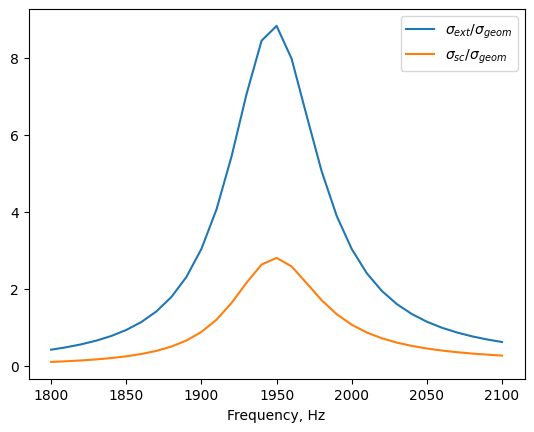

In [7]:
plt.plot(freq, sigma_ext / sigma_geom, label="$\\sigma_{ext} / \\sigma_{geom}$")
plt.plot(freq, sigma_sc / sigma_geom, label="$\\sigma_{sc} / \\sigma_{geom}$")
plt.legend()
plt.xlabel("Frequency, Hz")
plt.show()

Now we calculate the scattered and background pressure fields and apply the optical theorem for a spherical wave, given by:
$$
\sigma_\text{opt. t.} = \frac{4\pi}{k}\text{Im}\left[\frac{p_\text{s}(z)}{p_\text{b}(z)}\right]\frac{zR}{z+R}
$$

In [8]:
z, freq, p_s, p_b = get_results(model)

In [9]:
sigma_opt_t = []

c_host = 343.2
z0 = 0.7

for i in range(len(freq)):

    # Wavenumber
    k = 2 * np.pi * freq[i] / c_host

    # Use the farthest sampling point for extinction cross-section evaluation
    sigma_opt_t.append(
        (-4 * np.pi / k * np.imag(p_s[i] / p_b[i]) * z[i] * z0 / (z0 + z[i]))[-1]
    )

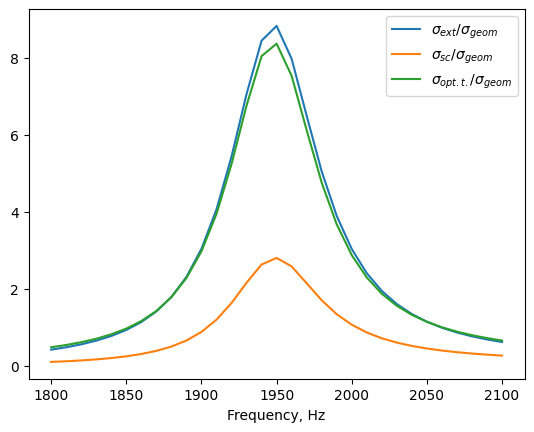

In [10]:
plt.plot(freq, sigma_ext / sigma_geom, label="$\\sigma_{ext} / \\sigma_{geom}$")
plt.plot(freq, sigma_sc / sigma_geom, label="$\\sigma_{sc} / \\sigma_{geom}$")
plt.plot(freq, sigma_opt_t / sigma_geom, label="$\\sigma_{opt. t.} / \\sigma_{geom}$")
plt.legend()
plt.xlabel("Frequency, Hz")
plt.show()

Save the model

In [11]:
model.save()

Disconnect the COMSOL client.

In [12]:
client.disconnect()